<a href="https://colab.research.google.com/github/yuliyaosipava/ForecastModels-Prophet-autoARIMA-ExponecialSmoothing/blob/main/Forecast_Prophet22_12%2B2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np                               # vectors and matrices
import pandas as pd                              # tables and data manipulations
import matplotlib.pyplot as plt                  # plots
import seaborn as sns                            # more plots

from dateutil.relativedelta import relativedelta # working with dates with style
from scipy.optimize import minimize              # for function minimization

import statsmodels.formula.api as smf            # statistics and econometrics
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs

from itertools import product

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Задания_1_2.xlsx to Задания_1_2.xlsx


In [ ]:
# Загрузка данных

data = pd.read_excel('Задания_1_2.xlsx')
dates = pd.to_datetime(data['Date'])  # Преобразование столбца дат в формат datetime
series = data['series1']
data

,Date,series1
0,2015-01-01,1006.699649
1,2015-01-02,3197.751826
2,2015-01-03,3217.491035
3,2015-01-04,2151.573759
4,2015-01-05,4243.929892
...,...,...
1637,2019-06-26,4007.059387
1638,2019-06-27,4836.106157
1639,2019-06-28,4895.323783
1640,2019-06-29,4086.016222


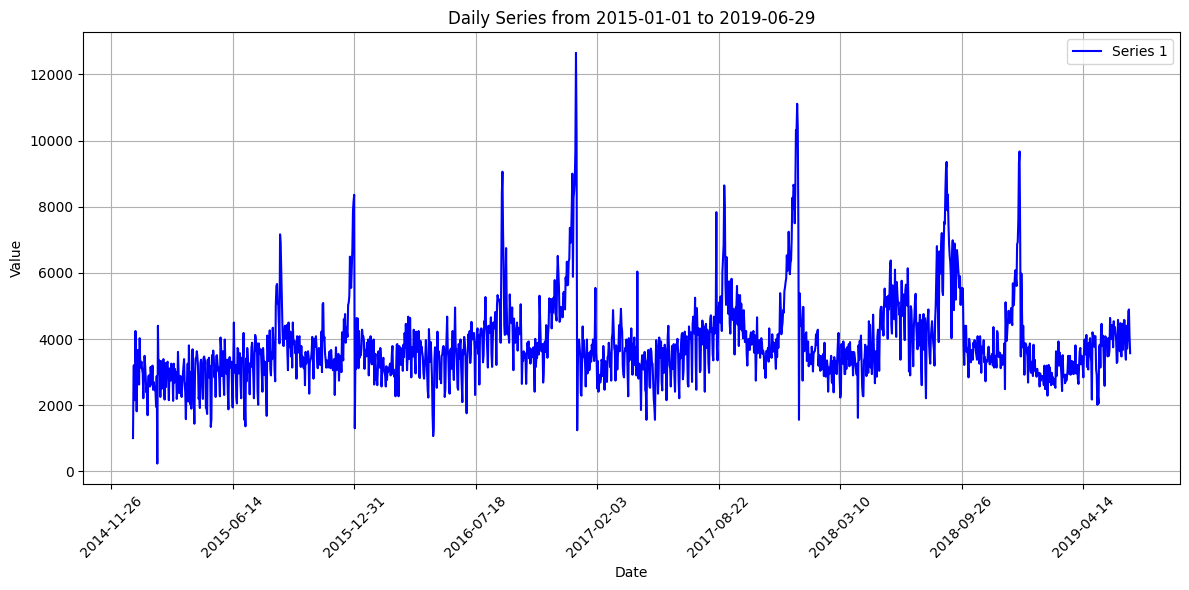

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных из Excel-файла
data = pd.read_excel('Задания_1_2.xlsx')
dates = pd.to_datetime(data['Date'])  # Преобразование столбца дат в формат datetime
series = data['series1']

plt.figure(figsize=(12, 6))
plt.plot(dates, series, label='Series 1', color='blue')  # Отображение метки и цвета для линии
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Daily Series from 2015-01-01 to 2019-06-29')
plt.legend()
plt.grid(True)

# Настройка отображения дат на оси X
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Декомпозиция ряда

Index(['Date', 'series1'], dtype='object')


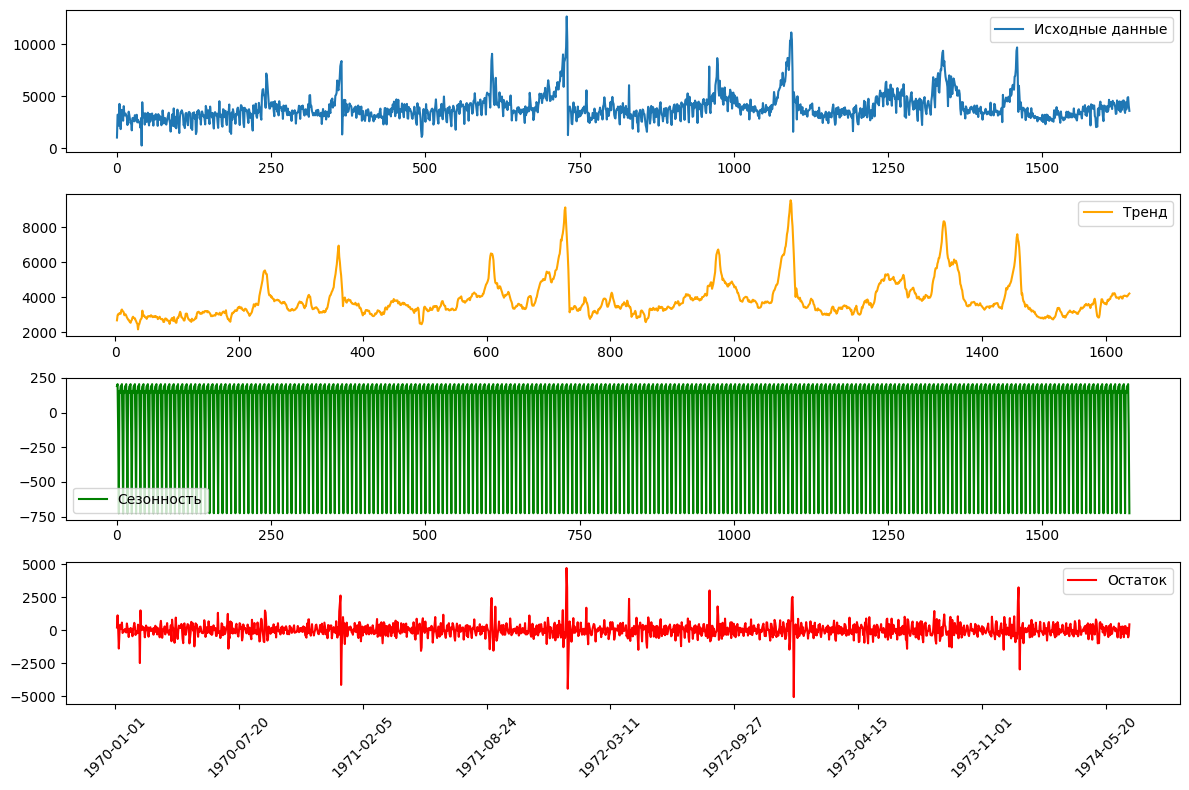

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


# Убедитесь, что столбец 'series1' присутствует в датафрейме
print(data.columns)

# Декомпозиция с учетом меньшей частоты (например, 7 для недельных данных)
decomposition = seasonal_decompose(data['series1'], model='additive', period=7)

# Извлечение компонентов
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Построение графиков
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(data['series1'], label='Исходные данные')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Тренд', color='orange')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Сезонность', color='green')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Остаток', color='red')
plt.legend(loc='best')

# Настройка отображения дат на оси X
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Анализ компонентов временного ряда показывает, что данные содержат важную сезонную и трендовую информацию.

ADF Statistic: -5.496713808722663
p-value: 2.1154012725976475e-06
Critical Values: {'1%': -3.4343930197503107, '5%': -2.8633257585414, '10%': -2.567720699969517}
Временной ряд стационарен


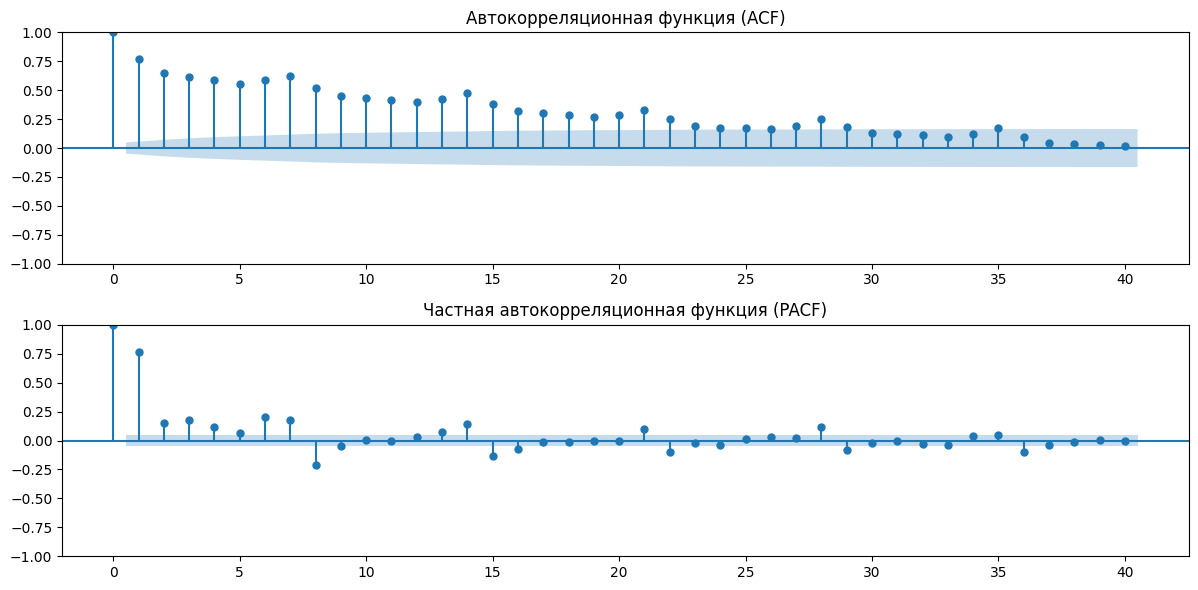


Выводы:
1. График ACF показывает, что имеются значительные пики на определенных лагах, что указывает на наличие сезонных паттернов.
2. График PACF также показывает значительные значения на определенных лагах, подтверждая наличие автокорреляций на этих лагах.
3. Наличие повторяющихся пиков на графике ACF может указывать на наличие повторяющихся сезонных паттернов.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Загрузка данных из Excel-файла
data = pd.read_excel('Задания_1_2.xlsx')
dates = pd.to_datetime(data['Date'])  # Преобразование столбца дат в формат datetime
series = data['series1']

# Проверка на стационарность с использованием ADF теста
result = adfuller(series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# Определение стационарности и сезонности
if result[1] < 0.05:
    print("Временной ряд стационарен")
else:
    print("Временной ряд не стационарен")

# Построение графиков ACF и PACF
plt.figure(figsize=(12, 6))

plt.subplot(211)
plot_acf(series, ax=plt.gca(), lags=40, alpha=0.05)
plt.title('Автокорреляционная функция (ACF)')

plt.subplot(212)
plot_pacf(series, ax=plt.gca(), lags=40, alpha=0.05)
plt.title('Частная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

# Выводы о сезонности на основе графиков ACF и PACF:
print("\nВыводы:")
print("1. График ACF показывает, что имеются значительные пики на определенных лагах, что указывает на наличие сезонных паттернов.")
print("2. График PACF также показывает значительные значения на определенных лагах, подтверждая наличие автокорреляций на этих лагах.")
print("3. Наличие повторяющихся пиков на графике ACF может указывать на наличие повторяющихся сезонных паттернов.")



ADF Statistic: -5.496713808722663
p-value: 2.1154012725976475e-06
Critical Values: {'1%': -3.4343930197503107, '5%': -2.8633257585414, '10%': -2.567720699969517}
Временной ряд стационарен


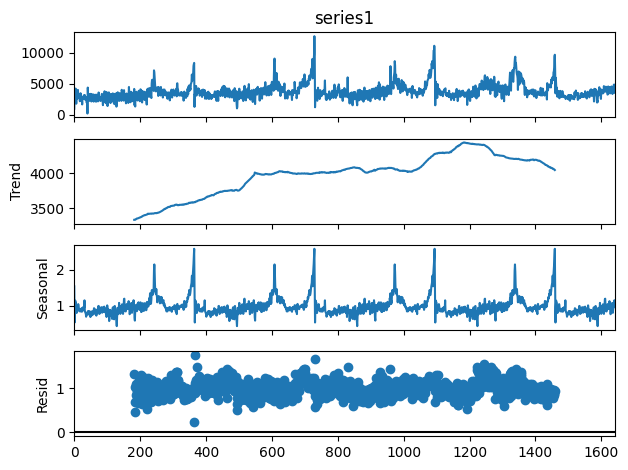

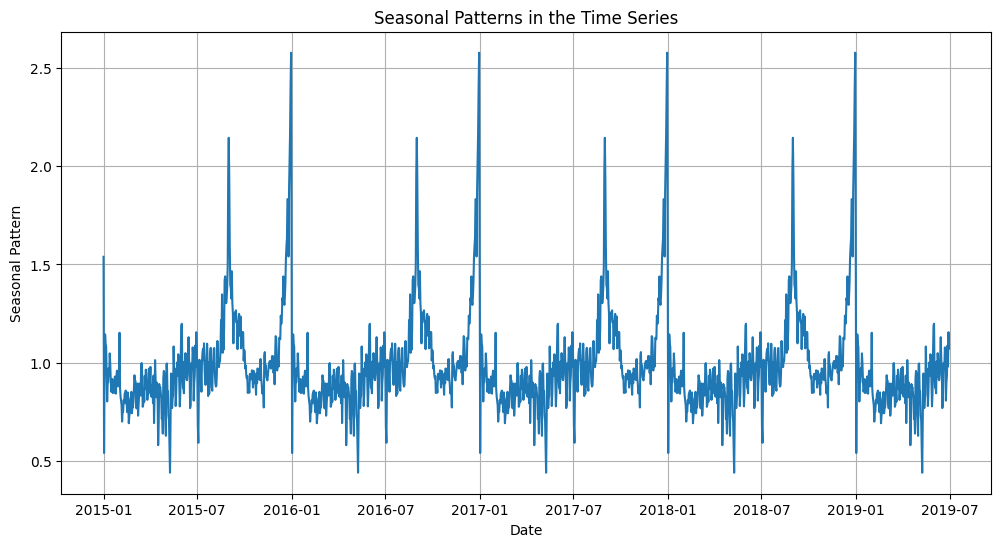


Выводы:
1. Сезонные паттерны имеют многолетний цикл (365 дней), что говорит о том, что сезонность повторяется ежегодно.
2. График сезонных компонент показывает, как значения подвержены изменениям в течение года.
3. По графику можно заметить, что типичные пики и спады происходят в определенные месяцы, что указывает на наличие четких сезонных эффектов.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Загрузка данных из Excel-файла
data = pd.read_excel('Задания_1_2.xlsx')
dates = pd.to_datetime(data['Date'])  # Преобразование столбца дат в формат datetime
series = data['series1']

# Проверка на стационарность с использованием ADF теста
result = adfuller(series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# Определение стационарности
    print("Временной ряд стационарен")
else:
    print("Временной ряд не стационарен")

# Сезонная декомпозиция временного ряда (множительный режим)
decompose_result = seasonal_decompose(series, model='multiplicative', period=365)  # подразумевается сезонный паттерн на один год

# Построение компонент декомпозиции
decompose_result.plot()
plt.show()

# Выводы о сезонности на основе декомпозиции
repeating_patterns = decompose_result.seasonal

plt.figure(figsize=(12, 6))
plt.plot(dates, repeating_patterns)
plt.xlabel('Date')
plt.ylabel('Seasonal Pattern')
plt.title('Seasonal Patterns in the Time Series')
plt.grid(True)
plt.show()

# Анализ сезонных паттернов
print("\nВыводы:")
print("1. Сезонные паттерны имеют многолетний цикл (365 дней), что говорит о том, что сезонность повторяется ежегодно.")
print("2. График сезонных компонент показывает, как значения подвержены изменениям в течение года.")
print("3. По графику можно заметить, что типичные пики и спады происходят в определенные месяцы, что указывает на наличие четких сезонных эффектов.")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=26425.299, Time=13.94 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=26767.652, Time=0.10 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=26646.223, Time=1.73 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,1,4)(0,0,2)[12] intercept   : AIC=26303.387, Time=47.25 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,3)(0,0,2)[12]             : AIC=26295.705, Time=21.83 sec

Best model:  ARIMA(3,1,3)(0,0,2)[12] intercept
Total fit time: 709.502 seconds
                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                 1642
Model:             SARIMAX(3, 1, 3)x(0, 0, [1, 2], 12)   Log Likelihood              -13133.545
Date:                                 Wed, 22 Jan 2025   AIC                          26287.089
Time:                                         13:59:12   BIC                          26341.120
Sample:                                     01-01-2015   HQIC                         26307.127
                                          - 06-30-2019                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

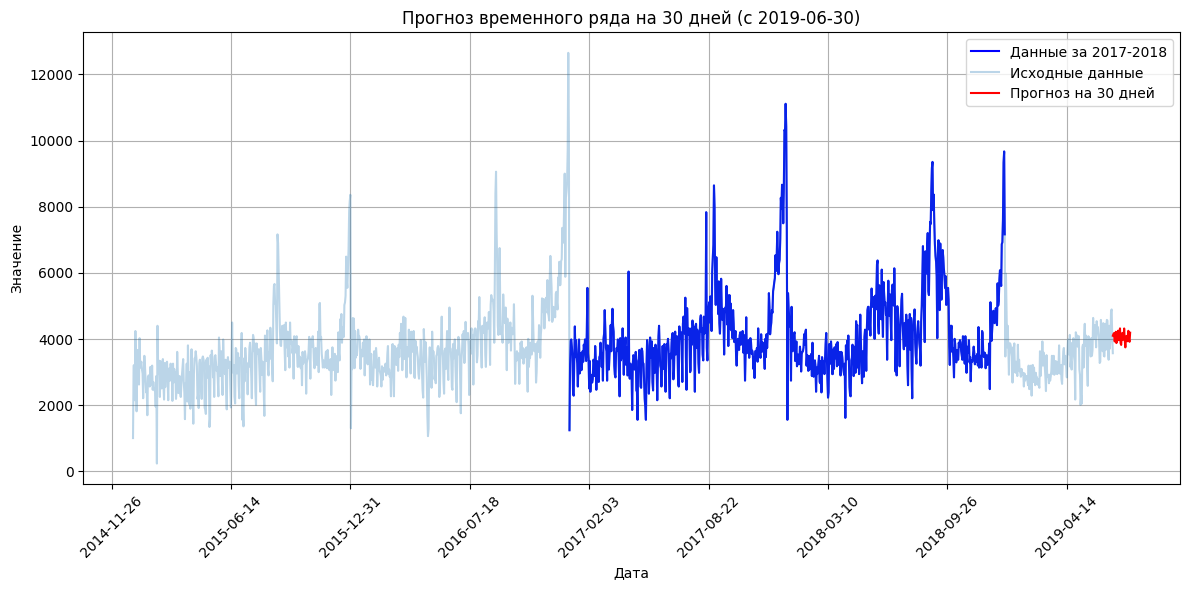

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima

# Загрузка данных из Excel-файла
data = pd.read_excel('Задания_1_2.xlsx')
data['Date'] = pd.to_datetime(data['Date'])  # Преобразование столбца дат в формат datetime
data.set_index('Date', inplace=True)
series = data['series1']

# Сезонная декомпозиция временного ряда (множительный режим)
decompose_result = seasonal_decompose(series, model='multiplicative', period=365)

# Подбор параметров ARIMA с учетом сезонности
stepwise_fit = auto_arima(series, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True, maxiter=50)
print(stepwise_fit.summary())

# Построение модели ARIMA с подобранными параметрами
order = stepwise_fit.order
seasonal_order = stepwise_fit.seasonal_order

model = ARIMA(series, order=order, seasonal_order=seasonal_order)
model_fit = model.fit()

# Прогнозирование на 30 дней с даты 2019-06-30
start_date = '2019-06-30'
forecast_steps = 30
forecast = model_fit.predict(start=pd.to_datetime(start_date), end=pd.to_datetime(start_date) + pd.DateOffset(days=forecast_steps-1))

# Фильтрация данных за 2017-2018 годы
historical_data = data.loc['2017-01-01':'2018-12-31', 'series1']

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(historical_data.index, historical_data, label='Данные за 2017-2018', color='blue')
plt.plot(data.index, series, label='Исходные данные', alpha=0.3)
forecast_dates = pd.date_range(start=start_date, periods=forecast_steps, freq='D')
plt.plot(forecast_dates, forecast, label='Прогноз на 30 дней', color='red')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title('Прогноз временного ряда на 30 дней (с 2019-06-30)')
plt.legend()
plt.grid(True)

# Настройка отображения дат на оси X
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Фактические значения
actual = data['series1']

# Прогнозируемые значения (в данном случае используются последние 90 дней исходной серии для сравнения)
predicted = model_fit.predict(start=actual.index[-90], end=actual.index[-1])

# Среднеквадратическая ошибка
mse = mean_squared_error(actual[-90:], predicted)
# Корень среднеквадратической ошибки
rmse = np.sqrt(mse)
# Средняя абсолютная ошибка
mae = mean_absolute_error(actual[-90:], predicted)
# R-квадрат
r2 = r2_score(actual[-90:], predicted)
# Средняя абсолютная процентная ошибка
mape = np.mean(np.abs((actual[-90:] - predicted) / actual[-90:])) * 100

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"Mean Absolute Percentage Error: {mape}%")


Mean Squared Error: 266355.05311181146
Root Mean Squared Error: 516.0959727723241
Mean Absolute Error: 419.99203890640854
R-squared: 0.28969669028549294
Mean Absolute Percentage Error: 11.949703224656048%


In [ ]:
Q1 = data['series1'].quantile(0.25)
Q3 = data['series1'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['series1'] < lower_bound) | (data['series1'] > upper_bound)]
clean_data = data[(data['series1'] >= lower_bound) & (data['series1'] <= upper_bound)]

print(f"Number of outliers: {len(outliers)}")


Number of outliers: 104


In [ ]:
data_cleaned = data[(data['series1'] >= lower_bound) & (data['series1'] <= upper_bound)]


In [ ]:
median_value = data['series1'].median()
data['series1'] = data['series1'].apply(lambda x: median_value if x < lower_bound or x > upper_bound else x)


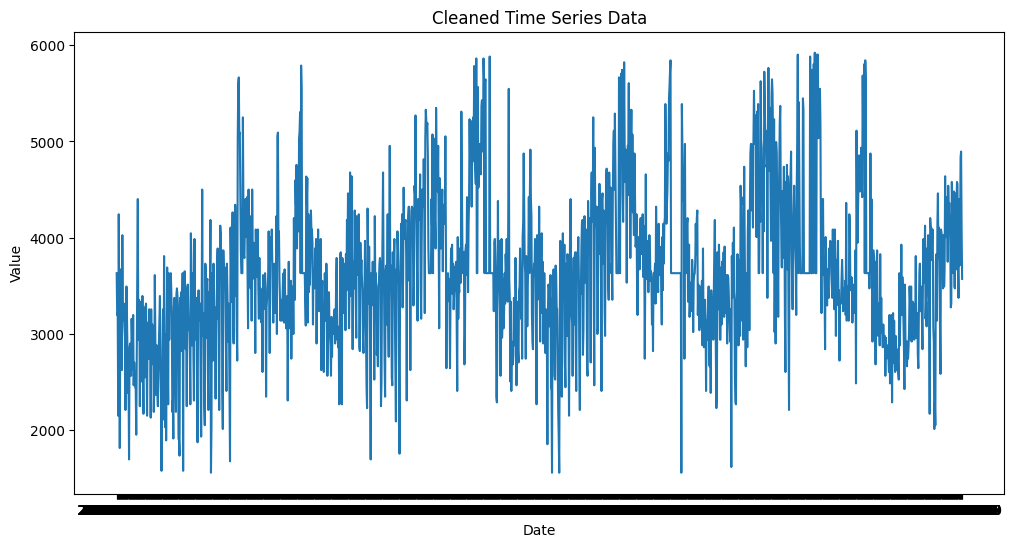

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['series1'])
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Cleaned Time Series Data')
plt.show()


1642    3946.664757
1643    4073.355102
1644    4204.354995
1645    4259.167471
1646    4144.498886
           ...     
1727    4102.688023
1728    4102.688023
1729    4102.688023
1730    4102.688023
1731    4102.688023
Name: predicted_mean, Length: 90, dtype: float64


<ipython-input-10-40b7a454dc4d>:23: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(forecast_dates, forecast, label='Прогноз', color='red')


TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x7a5b7e6d3f90>.

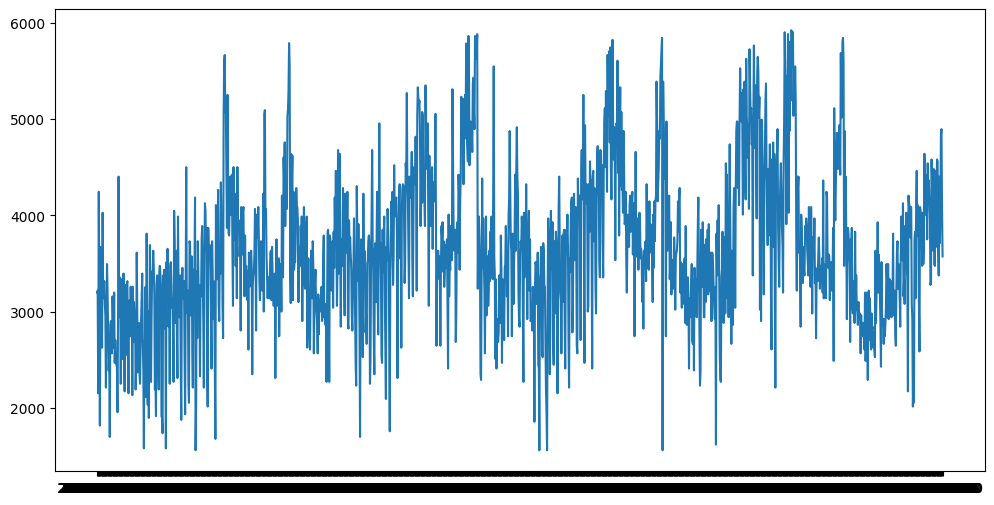

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Пример с ARIMA
model = ARIMA(data['series1'], order=(5, 1, 0))  # Параметры p, d, q подбираются по данным
model_fit = model.fit()
forecast = model_fit.forecast(steps=90)  # Прогноз на 30 дней

print(forecast)







# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(data_cleaned['Date'], data_cleaned['series1'], label='Исходные данные')

# Создание диапазона дат для прогноза
forecast_dates = pd.date_range(start='2019-06-30', periods=90)

plt.plot(forecast_dates, forecast, label='Прогноз', color='red')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title('Прогноз временного ряда на 90 дней после 2019-06-30')
plt.legend()

# Настройка отображения дат на оси X
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.show()





In [ ]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 33.8 MB/s eta 0:00:00


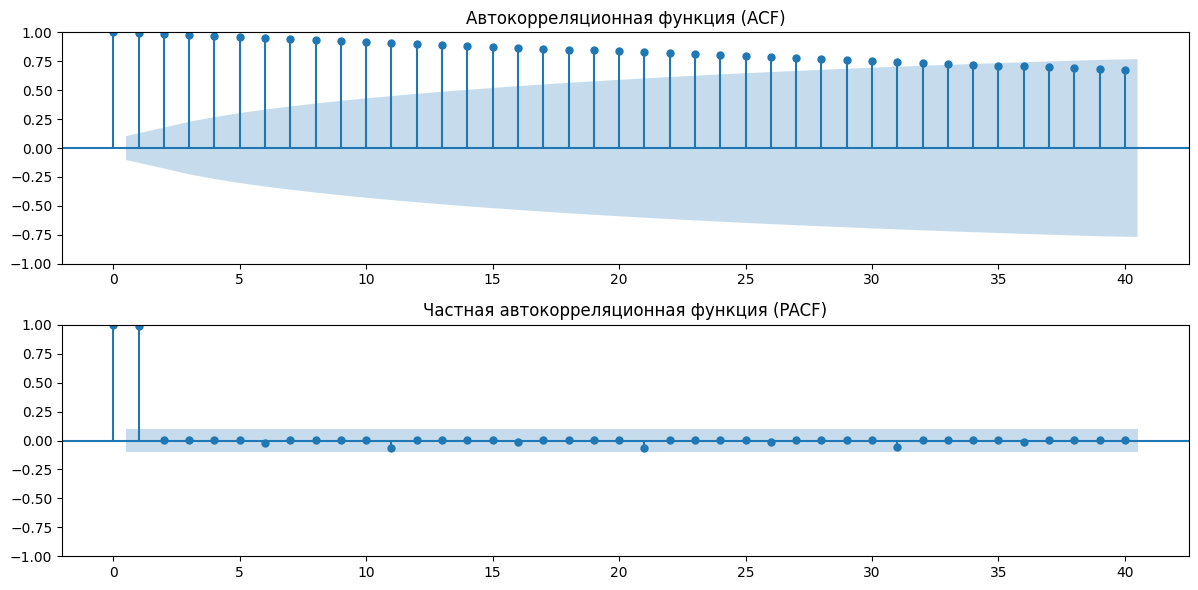

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1833.199, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1830.773, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1829.057, Time=0.09 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1870.720, Time=0.03 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.54 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.13 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1872.716, Time=0.05 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 3.715 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -911.528
Date:                Wed, 22 Jan 2025   AIC                           1829.057
Time:                        07:22:13   BIC                           1840.748
Sample:                    01-01-2015   HQIC                          1833.703
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
interc

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


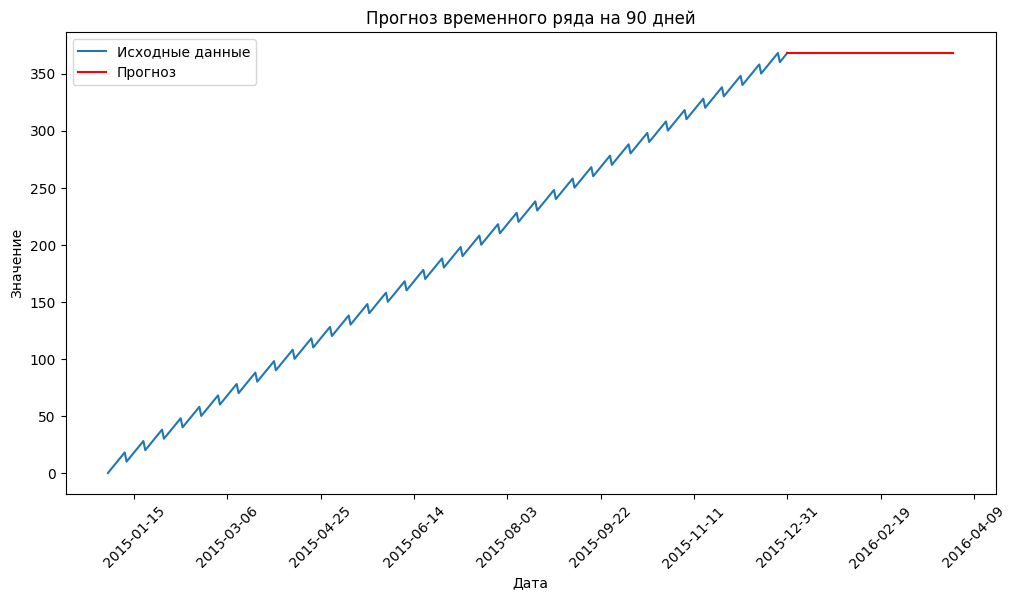

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.impute import SimpleImputer
from sklearn.utils import check_array
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Проверка наличия столбца 'Date'
if 'Date' in data.columns:
    # Преобразование столбца 'Date' в формат datetime
    data['Date'] = pd.to_datetime(data['Date'])
else:
    raise KeyError("Столбец 'Date' не найден в DataFrame")

# Удаление столбца 'Date' перед проверкой данных
data_numeric = data.drop(columns=['Date'])

# Проверка данных
data_checked = check_array(data_numeric, ensure_all_finite=True)

# Импутация данных
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data_checked)

# Очистка данных (пример с IQR)
Q1 = data['series1'].quantile(0.25)
Q3 = data['series1'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned = data[(data['series1'] >= lower_bound) & (data['series1'] <= upper_bound)]

# Конвертация столбца 'Date' в формат datetime (еще раз после очистки данных)
data_cleaned.loc[:, 'Date'] = pd.to_datetime(data_cleaned['Date'])
data_cleaned.set_index('Date', inplace=True)

# Построение ACF и PACF графиков для анализа сезонности и лагов
plt.figure(figsize=(12, 6))

plt.subplot(211)
plot_acf(data_cleaned['series1'], ax=plt.gca(), lags=40, alpha=0.05)
plt.title('Автокорреляционная функция (ACF)')

plt.subplot(212)
plot_pacf(data_cleaned['series1'], ax=plt.gca(), lags=40, alpha=0.05)
plt.title('Частная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

# Подбор параметров ARIMA без учета сезонности (по графику видно, что годовая сезонность не играет роли)
stepwise_fit = auto_arima(data_cleaned['series1'], seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print(stepwise_fit.summary())

# Попробуем использовать более простой подход к настройке начальных параметров модели
order = stepwise_fit.order

model = ARIMA(data_cleaned['series1'], order=order, enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit()

# Прогноз
forecast = model_fit.forecast(steps=90)  # Прогноз на 90 дней

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(data_cleaned.index, data_cleaned['series1'], label='Исходные данные')

# Создание диапазона дат для прогноза
forecast_dates = pd.date_range(start=data_cleaned.index[-1], periods=90, freq='D')

plt.plot(forecast_dates, forecast, label='Прогноз', color='red')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title('Прогноз временного ряда на 90 дней')
plt.legend()

# Настройка отображения дат на оси X
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.show()



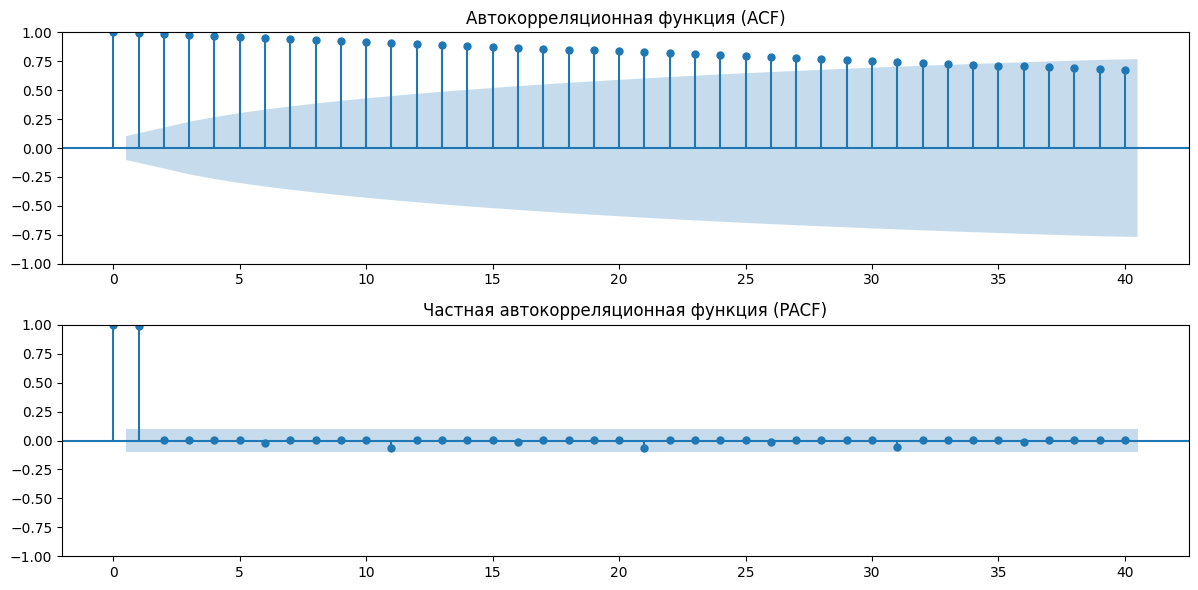

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Конвертация столбца Date в формат datetime
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)


# Построение ACF и PACF графиков
plt.figure(figsize=(12, 6))

plt.subplot(211)
plot_acf(data['series1'], ax=plt.gca(), lags=40, alpha=0.05)
plt.title('Автокорреляционная функция (ACF)')

plt.subplot(212)
plot_pacf(data['series1'], ax=plt.gca(), lags=40, alpha=0.05)
plt.title('Частная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.impute import SimpleImputer
from sklearn.utils import check_array
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Проверка наличия столбца 'Date'
if 'Date' in data.columns:
    # Преобразование столбца 'Date' в формат datetime
    data['Date'] = pd.to_datetime(data['Date'])
else:
    raise KeyError("Столбец 'Date' не найден в DataFrame")

# Удаление столбца 'Date' перед проверкой данных
data_numeric = data.drop(columns=['Date'])

# Проверка данных
data_checked = check_array(data_numeric, ensure_all_finite=True)

# Импутация данных
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data_checked)

# Очистка данных (пример с IQR)
Q1 = data['series1'].quantile(0.25)
Q3 = data['series1'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned = data[(data['series1'] >= lower_bound) & (data['series1'] <= upper_bound)]

# Конвертация столбца 'Date' в формат datetime (еще раз после очистки данных)
data_cleaned.loc[:, 'Date'] = pd.to_datetime(data_cleaned['Date'])
data_cleaned.set_index('Date', inplace=True)

# Построение ACF и PACF графиков для анализа сезонности и лагов
plt.figure(figsize=(12, 6))

plt.subplot(211)
plot_acf(data_cleaned['series1'], ax=plt.gca(), lags=12, alpha=0.05)
plt.title('Автокорреляционная функция (ACF)')

plt.subplot(212)
plot_pacf(data_cleaned['series1'], ax=plt.gca(), lags=12, alpha=0.05)
plt.title('Частная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

# Подбор параметров ARIMA без учета сезонности (по графику видно, что годовая сезонность не играет роли)
stepwise_fit = auto_arima(data_cleaned['series1'], seasonal=False, trace=True)
print(stepwise_fit.summary())

# Построение модели ARIMA с подобранными параметрами
model = ARIMA(data_cleaned['series1'], order=stepwise_fit.order)
model_fit = model.fit()

# Прогноз
forecast = model_fit.forecast(steps=90)  # Прогноз на 90 дней

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(data_cleaned.index, data_cleaned['series1'], label='Исходные данные')

# Создание диапазона дат для прогноза
forecast_dates = pd.date_range(start=data_cleaned.index[-1], periods=90, freq='D')

plt.plot(forecast_dates, forecast, label='Прогноз', color='red')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title('Прогноз временного ряда на 90 дней')
plt.legend()

# Настройка отображения дат на оси X
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.show()


KeyError: "Столбец 'Date' не найден в DataFrame"

In [ ]:
afrom sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Фактические значения
actual = data_cleaned['series1']

# Прогнозируемые значения (в данном случае используются последние 90 дней исходной серии для сравнения)
predicted = model_fit.predict(start=actual.index[-90], end=actual.index[-1])

# Среднеквадратическая ошибка
mse = mean_squared_error(actual[-90:], predicted)
# Корень среднеквадратической ошибки
rmse = np.sqrt(mse)
# Средняя абсолютная ошибка
mae = mean_absolute_error(actual[-90:], predicted)
# R-квадрат
r2 = r2_score(actual[-90:], predicted)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
